# Example 4: Quarter-Disc Elasticity Simulation with FLASh

This notebook demonstrates the simulation of a quarter-disc domain with one fixed side and a downward traction on the other. The example validates solver accuracy and boundary condition handling using reduced order models (ROMs) and the FLASh library.

## 1. Import Required Libraries and Modules

Import numpy and all necessary FLASh modules.

In [1]:
import numpy as np

from FLASh.utils import Communicators
from FLASh.mesh import GlobalDofsManager, SplineGeometry, gyroid
from FLASh.pde import Elasticity, BDDC
from FLASh.rom import MDEIM
from _paths import ROM_DATA_DIR

## 2. Load Reduced Order Models (ROM)

Set parameter ranges and dimensions. Initialize MDEIM models for K_core, M_core, and bM_core. Load model data from files using `set_up_from_files`. Load the full K_core array with numpy.

In [2]:
# Set parameter ranges and dimensions
epsilon_min = 0.1
epsilon_max = 0.9
n_rom = 2
p_rom = 6
d_rom = 4
p0 = np.array([epsilon_min] * d_rom)
p1 = np.array([epsilon_max] * d_rom)

# Initialize and load ROM models
k_core_model = MDEIM(n_rom, p_rom, p0, p1)
k_core_model.set_up_from_files(str(ROM_DATA_DIR / "schwarz_diamond_3" / "K_core"))

m_core_model = MDEIM(n_rom, p_rom, p0, p1)
m_core_model.set_up_from_files(str(ROM_DATA_DIR / "schwarz_diamond_3" / "M_core"))

bm_core_model = MDEIM(n_rom, p_rom, p0, p1)
bm_core_model.set_up_from_files(str(ROM_DATA_DIR / "schwarz_diamond_3" / "bM_core"))

K_core_full = np.load(str(ROM_DATA_DIR / "schwarz_diamond_3" / "K_core" / "full_array.npy"))

## 3. Define Geometry and Mapping Functions

Define the `map` function for the quarter-disc transformation. Define the `parameter_function` for the geometry. Set spline and basis degrees, and geometry options.

In [3]:
# Geometry and mapping functions
P0 = np.array([0.0, 0.0])
P1 = np.array([1.0, 1.0])

def map(x, y, r=[0.6, 1.0], theta=[1.5, 2.0]):
    tx = theta[0] + (theta[1] - theta[0]) * x
    ty = r[0] + (r[1] - r[0]) * y
    return np.stack([ty * np.cos(np.pi * tx), ty * np.sin(np.pi * tx), 0 * tx], axis=-1)

def parameter_function(X):
    val = 0.9 - 0.8 * X[0]
    return np.clip(val, 0.1, 0.9)

basis_degree = 8
spline_degree = 2

geometry_opts = {
    "basis_degree": basis_degree,
    "spline_degree": spline_degree,
    "periodic": False
}

## 4. Set Boundary and Source Conditions

Define the `source`, `h_bc` (homogeneous Dirichlet), and `nh_bc` (Neumann) boundary condition functions. Set up the `exterior_bc` list for boundary assignment.

In [4]:
# Source and boundary conditions
def source(X):
    return (0.0 + 0.0 * X[0], 0.0 + 0.0 * X[0])

def h_bc(X):
    return (0.0 + 0.0 * X[0], 0.0 + 0.0 * X[0])

def nh_bc(X):
    return (0.0 + 0.0 * X[0], -0.1 + 0.0 * X[0])

exterior_bc = [
    (
        0,
        h_bc,
        lambda x: np.isclose(x[0], P0[0]),
        0
    ),
    (
        1,
        nh_bc,
        lambda x: np.isclose(x[0], P1[0]),
        0
    )
]

## 5. Configure Simulation and Solver Parameters

Set stabilization parameters and solver options for BDDC and the global degrees of freedom manager.

In [5]:
# Simulation and solver parameters
stabilization = 5e-4
stabilize = True

sbdmn_opts = {
    "stabilize": True,
    "stabilization": stabilization,
    "assemble": True
}

gdm_opts = {
    "subdomain_opts": sbdmn_opts
}

opts = {
    "global_dofs_manager_opts": gdm_opts
}

## 6. Create Geometry and Set Parameter Field

Define the knot vectors for the spline geometry. Create the `SplineGeometry` object using `interpolate_map`. Set the parameter field on the coarse mesh using `parameter_function`.

In [6]:
# Knot vectors and geometry creation
i = 1
n = [4 * i, 2 * i]

P0 = np.array([0.0, 0.0])
P1 = np.array([1.0, 1.0])

knots_x = [P0[0]] * spline_degree + list(np.linspace(P0[0], P1[0], n[0] + 1)) + [P1[0]] * spline_degree
knots_y = [P0[1]] * spline_degree + list(np.linspace(P0[1], P1[1], n[1] + 1)) + [P1[1]] * spline_degree

gyroid_func = gyroid.SchwarzDiamond().make_function()

geometry = SplineGeometry.interpolate_map(
    [knots_x, knots_y],
    map,
    gyroid_func,
    geometry_opts
)

geometry.coarse_mesh.set_parameter_field_from_function(parameter_function)

The macrogeometry and its associated cuantities can be visualized with helper funtions form the `SplineGeometry` class. `plot` show the geometry, `plot_det` shows the determinant of the jacobian transformation and `coeff_error` show the error of the assembly coefficients due to the polinomial projection.  

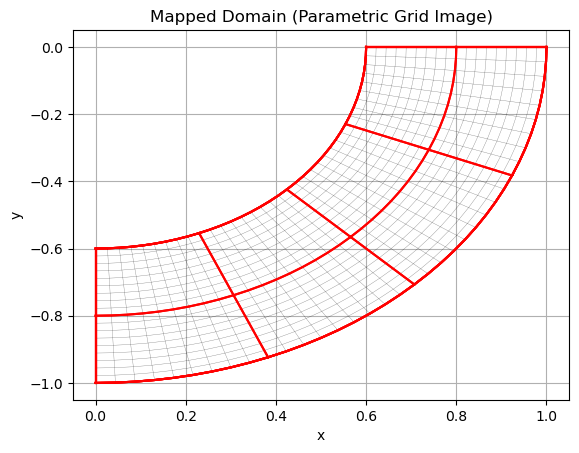

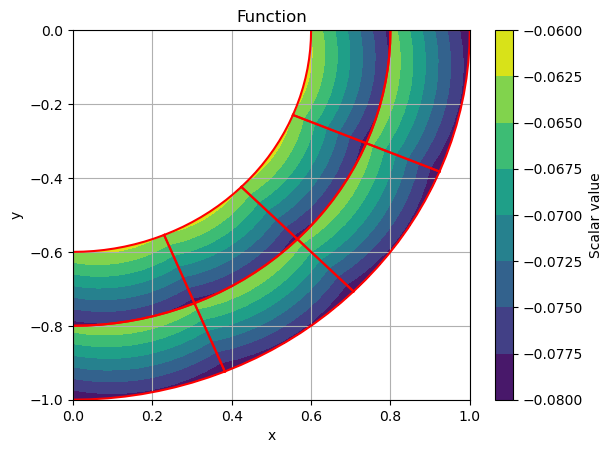

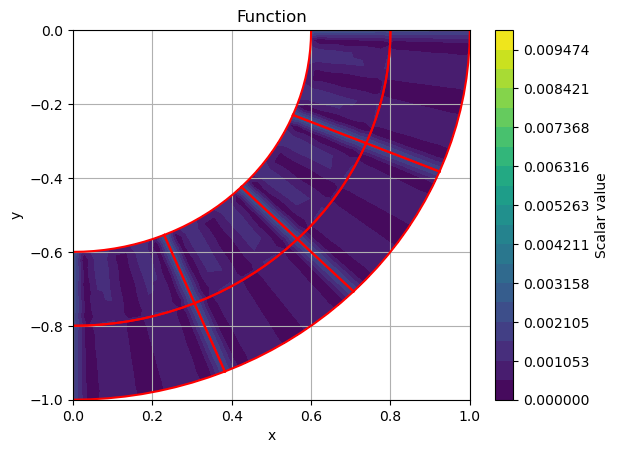

In [7]:
geometry.plot()
geometry.plot_det()
geometry.coeff_error()

## 7. Set Up and Solve the PDE Problem

Create the `Elasticity` PDE object with all required arguments. Instantiate the `BDDC` solver, call `setup()` and `solve()` methods.

In [8]:
# Set up and solve the PDE problem
communicators = Communicators()

elasticity_pde = Elasticity(
    exterior_bc=exterior_bc,
    source=source,
    E=5,
    nu=0.25,
    K_model=k_core_model,
    M_model=m_core_model,
    bM_model=bm_core_model,
    K_full_core=K_core_full
)

solver = BDDC(geometry, elasticity_pde, communicators, opts=opts)
solver.setup()
solver.solve()


Subdomains assembly.
Subdomains assembly: 12.5%
Subdomains assembly: 75.0%
Subdomains assembly: 100.0%
#### BDDC Solver ####

Number of subdomains: 8.
Number of global active dofs: 1088.

Number of iterations: 10.


Setup time:  0.14945484500003658
Assemble time:  0.09041729899990969
Solve time:  0.03880654599970512
Total time:  0.2786786899996514




## 8. Visualize the Solution

Call `plot_solution()` on the solver to display the computed displacement field.

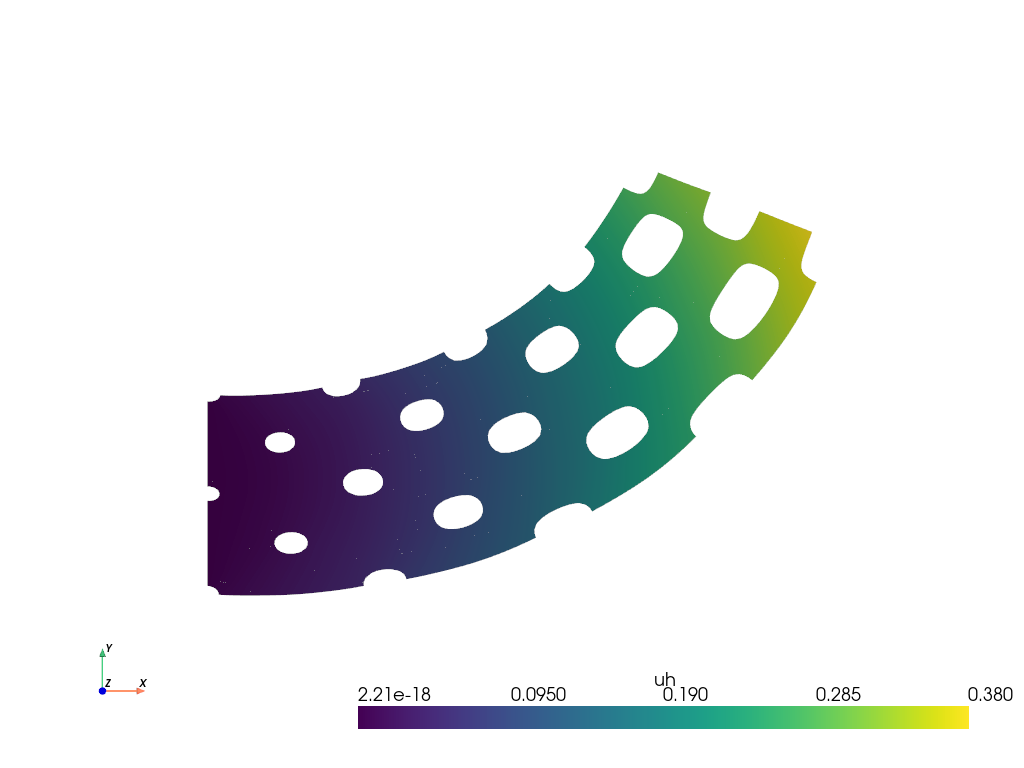

In [9]:
# Visualize the solution
solver.plot_solution()